## Downloading with GEE

In [1]:
# install with
# !pip install terragon-downloader[gee]

In [ ]:
import terragon
import geopandas as gpd
import xarray as xr
import ee
from utils import visualize_sat_images, dict_to_tree

In [2]:
# we will use the sample data to download a minicube
# other datasets are described here: https://developers.google.com/earth-engine/datasets
gdf = gpd.read_file("data/TUM_OTN.geojson")
arguments = dict(
    shp=gdf,
    collection="COPERNICUS/S2_SR_HARMONIZED",
    start_date="2021-01-01",
    end_date="2021-01-05",
    bands=["B2", "B3", "B4"],
    resolution=10,
    download_folder="tests/download/",
)
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Initialize GEE

In [3]:
# to authenticate you need to have an google account and be part of the google earth engine program
# register here: https://code.earthengine.google.com/register/

# ee.Authenticate() # authenticate if needed and not done before (providing credentials)
# usage of cloud projects are enforced in the future, see https://developers.google.com/earth-engine/guides/usage
ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")
# ee.Initialize(opt_url='https://earthengine-highvolume.googleapis.com', project=<your_project>)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [4]:
tg = terragon.init("gee")  # credentials are provided through ee.Authenticate()

### Finding collections

In [5]:
# This is not supported by GEE. Please, visit their website: https://developers.google.com/earth-engine/datasets
tg.retrieve_collections()

NotImplementedError: GEE does not have a collection endpoint. Please, visit https://developers.google.com/earth-engine/datasets/catalog

### download (with geedim backend)

In [5]:
# clipped tile tifs are downloaded with geedim and then merged into a single xarray dataset
ds = tg.create(**arguments, num_workers=10)
# or
# items = tg.search(**arguments, num_workers=10)
# ds = tg.download(items)
ds

...1dafa549a7b926804f8ffe9adcda829cad459dd5fdc042.tif: |                                                      …

...1dafa549a7b926804f8ffe9adcda829cad459dd5fdc042.tif: |                                                      …

<xarray.Dataset> Size: 6kB
Dimensions:      (x: 28, y: 17, time: 2)
Coordinates:
  * x            (x) float64 224B 11.65 11.65 11.65 11.65 ... 11.66 11.66 11.66
  * y            (y) float64 136B 48.06 48.06 48.06 48.06 ... 48.05 48.05 48.05
  * time         (time) datetime64[ns] 16B 2021-01-01 2021-01-03
    spatial_ref  int64 8B 0
Data variables:
    B2           (time, y, x) uint16 2kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    B3           (time, y, x) uint16 2kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    B4           (time, y, x) uint16 2kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
Attributes:
    crs:          EPSG:4326
    data_source:  GEE
    collection:   COPERNICUS/S2_SR_HARMONIZED

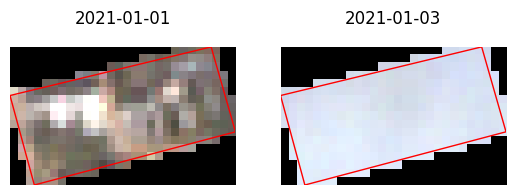

In [6]:
visualize_sat_images(ds, gdf, list(reversed(arguments["bands"])))

In [7]:
# the ouptut of the search is an ee ImageCollection
tg.search(**arguments)

### Special arguments for GEE

In [8]:
# downloaded tile tifs are removed by default when creating a minicube, this behavior can be change with rm_tmp_files=False
ds = tg.create(**arguments, rm_tmp_files=False)

...1dafa549a7b926804f8ffe9adcda829cad459dd5fdc042.tif: |                                                      …

...1dafa549a7b926804f8ffe9adcda829cad459dd5fdc042.tif: |                                                      …